Simulating dual-state oscillation and collapse...
Simulation complete. Total steps: 200, Observation interval: 20


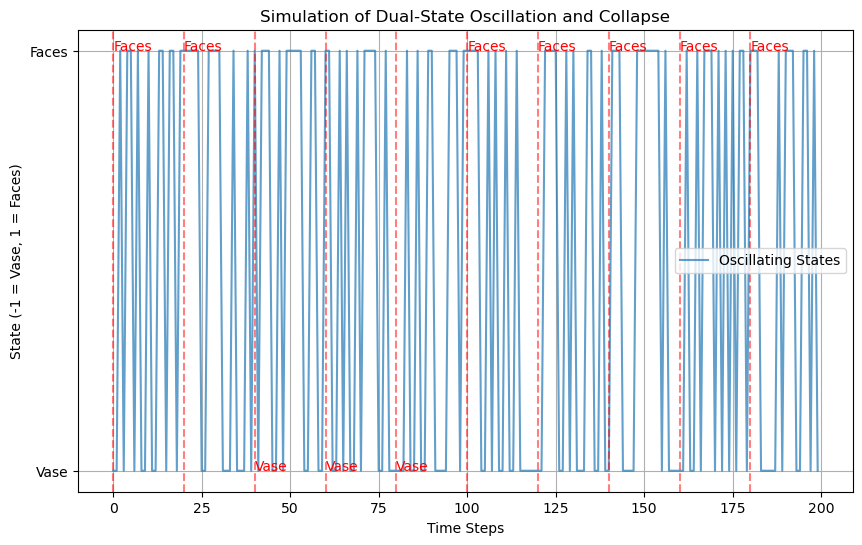

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

def simulate_dual_wave_states(total_steps=200, observation_interval=20):
    """
    Simulates a dual-state wave system oscillating between two interpretations (e.g., faces and vase).

    Parameters:
    - total_steps: Total number of simulation steps.
    - observation_interval: Number of steps before a blink (observation event).

    Returns:
    - states: The states over time ("Faces" or "Vase").
    - collapsed_states: The states when observed (collapsed state).
    """
    states = []
    collapsed_states = []

    # Dual-state probabilities
    state_probabilities = {"Faces": 0.5, "Vase": 0.5}
    current_state = random.choice(["Faces", "Vase"])

    for step in range(total_steps):
        # Oscillation: Randomly switch between states based on probabilities
        if random.random() < state_probabilities["Faces"]:
            current_state = "Faces"
        else:
            current_state = "Vase"
        states.append(current_state)

        # Observation (blink) forces collapse to one state
        if step % observation_interval == 0:
            collapsed_state = random.choice(["Faces", "Vase"])
            collapsed_states.append((step, collapsed_state))

    return states, collapsed_states

def visualize_dual_wave_states(states, collapsed_states, total_steps=200):
    """
    Visualizes the dual-state wave system and its observed (collapsed) states.

    Parameters:
    - states: List of states over time.
    - collapsed_states: List of collapsed states due to observation.
    - total_steps: Total number of simulation steps.
    """
    time_steps = np.arange(total_steps)
    state_mapping = {"Faces": 1, "Vase": -1}
    state_values = [state_mapping[state] for state in states]

    plt.figure(figsize=(10, 6))

    # Plot the oscillating dual states
    plt.plot(time_steps, state_values, label="Oscillating States", alpha=0.7)

    # Highlight the collapsed states
    for step, state in collapsed_states:
        plt.axvline(x=step, color='red', linestyle='--', alpha=0.5)
        plt.text(step, state_mapping[state], state, color='red', fontsize=10)

    plt.title("Simulation of Dual-State Oscillation and Collapse")
    plt.xlabel("Time Steps")
    plt.ylabel("State (-1 = Vase, 1 = Faces)")
    plt.yticks([-1, 1], ["Vase", "Faces"])
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
    total_steps = 200
    observation_interval = 20

    print("Simulating dual-state oscillation and collapse...")
    states, collapsed_states = simulate_dual_wave_states(total_steps, observation_interval)
    print(f"Simulation complete. Total steps: {total_steps}, Observation interval: {observation_interval}")

    visualize_dual_wave_states(states, collapsed_states, total_steps)

if __name__ == "__main__":
    main()


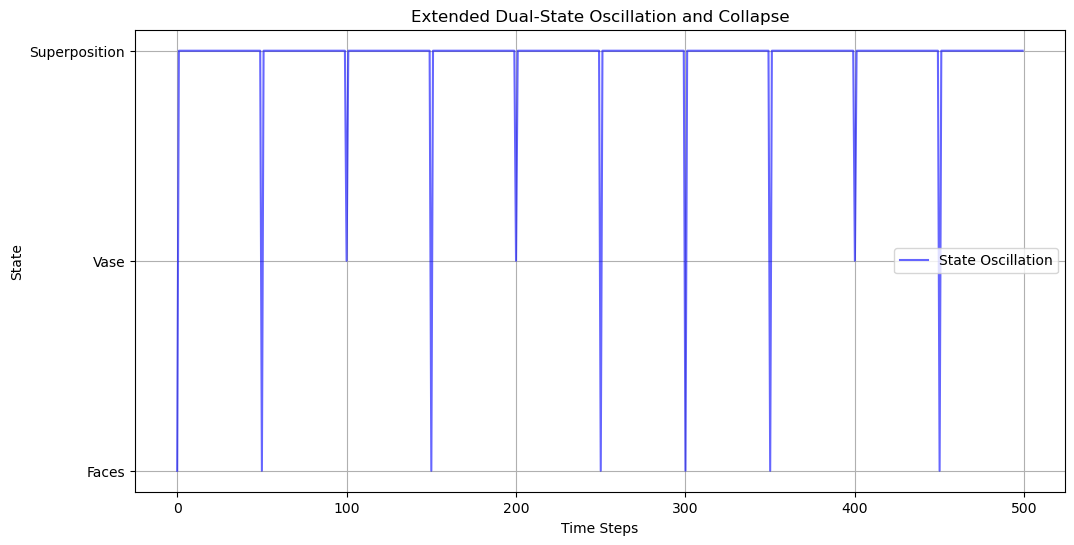

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
time_steps = 500
observation_interval = 50
noise_level = 0.1
states = ["Faces", "Vase", "Superposition"]
probabilities = [0.5, 0.5, 0.0]  # Initial probabilities

# Initialize state history
state_history = []

# Function to collapse state
def collapse_state(probs):
    max_prob = max(probs)
    return np.random.choice(states, p=[p / sum(probs) for p in probs])

# Simulate dual-state oscillation with noise
for t in range(time_steps):
    # Add noise to probabilities
    noisy_probs = [p + np.random.uniform(-noise_level, noise_level) for p in probabilities]
    noisy_probs = [max(0, p) for p in noisy_probs]  # Ensure no negative probabilities
    noisy_probs = [p / sum(noisy_probs) for p in noisy_probs]  # Normalize

    # Oscillate probabilities
    probabilities[0] = 0.5 + 0.5 * np.sin(2 * np.pi * t / observation_interval)
    probabilities[1] = 1 - probabilities[0]

    if t % observation_interval == 0:
        # Collapse state at observation intervals
        collapsed_state = collapse_state(noisy_probs)
        probabilities = [0.0, 0.0, 0.0]  # Reset probabilities after collapse
        probabilities[states.index(collapsed_state)] = 1.0
        state_history.append((t, collapsed_state))
    else:
        state_history.append((t, "Superposition"))

# Extract time and states
time, observed_states = zip(*state_history)

# Plot results
plt.figure(figsize=(12, 6))
plt.title("Extended Dual-State Oscillation and Collapse")
plt.plot(time, [states.index(s) for s in observed_states], label="State Oscillation", color="blue", alpha=0.6)
plt.xlabel("Time Steps")
plt.ylabel("State")
plt.yticks(range(len(states)), states)
plt.legend()
plt.grid()
plt.show()


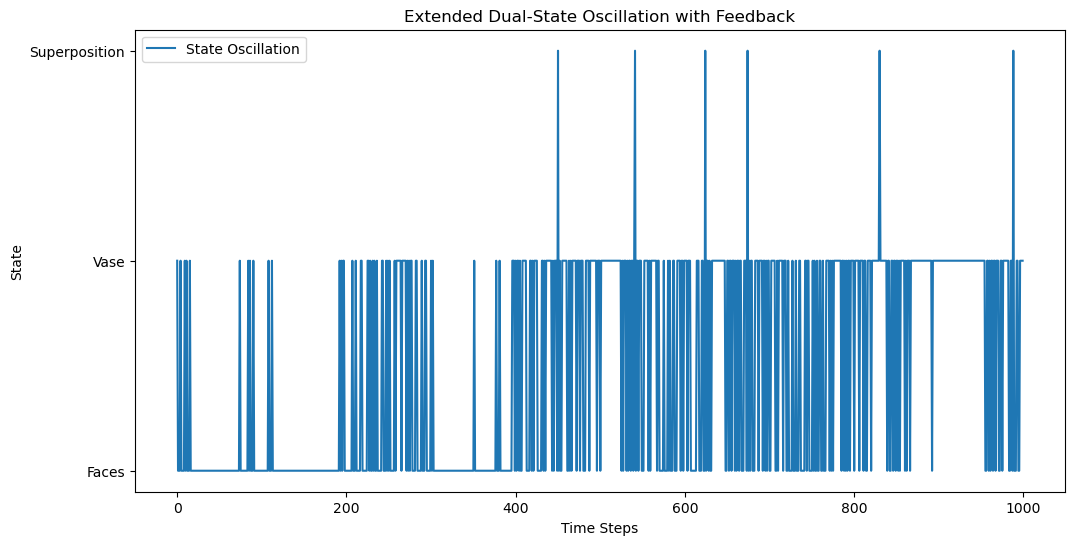

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
time_steps = 1000
states = ["Faces", "Vase", "Superposition"]
state_probabilities = np.array([0.4, 0.4, 0.2])  # Initial probabilities
feedback_strength = 0.1
noise_level = 0.05

# Tracking states over time
state_history = []

# Feedback loop
def feedback_adjustment(current_state, probabilities):
    if current_state == "Faces":
        probabilities[0] += feedback_strength
    elif current_state == "Vase":
        probabilities[1] += feedback_strength
    probabilities[2] -= feedback_strength  # Decrease superposition likelihood
    return probabilities

# Simulation
for t in range(time_steps):
    # Add noise to probabilities
    state_probabilities += np.random.uniform(-noise_level, noise_level, 3)
    state_probabilities = np.clip(state_probabilities, 0, None)  # Ensure no negative probabilities
    state_probabilities /= np.sum(state_probabilities)  # Normalize to sum to 1

    # Choose a state based on probabilities
    current_state = np.random.choice(states, p=state_probabilities)
    state_history.append(current_state)

    # Apply feedback adjustment
    state_probabilities = feedback_adjustment(current_state, state_probabilities)
    state_probabilities = np.clip(state_probabilities, 0, None)  # Ensure no negative probabilities
    state_probabilities /= np.sum(state_probabilities)  # Normalize again after feedback adjustment

# Visualize results
time = np.arange(time_steps)
state_indices = [states.index(state) for state in state_history]

plt.figure(figsize=(12, 6))
plt.plot(time, state_indices, label="State Oscillation")
plt.yticks(ticks=range(len(states)), labels=states)
plt.xlabel("Time Steps")
plt.ylabel("State")
plt.title("Extended Dual-State Oscillation with Feedback")
plt.legend()
plt.show()


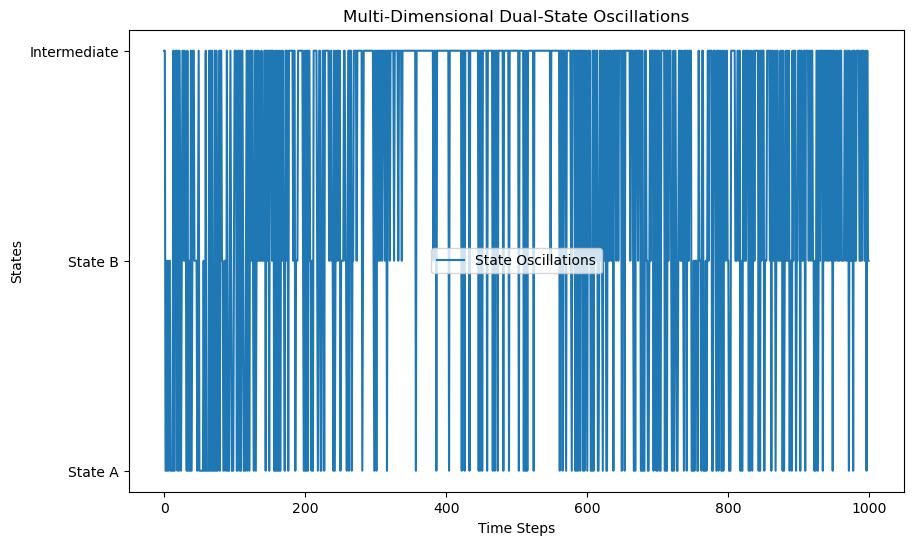

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define states
states = ['State A', 'State B', 'Intermediate']
state_map = {state: i for i, state in enumerate(states)}

# Initialize parameters
num_steps = 1000
state_history = []
external_stimuli = np.random.uniform(-0.5, 0.5, num_steps)  # Chaos from environment
feedback = 0.8  # Controls state persistence

# State probabilities
current_state = np.random.choice(states)
state_probabilities = np.array([0.33, 0.33, 0.33])  # Equal starting probabilities

# Simulate state transitions
for step in range(num_steps):
    # Modify probabilities with external stimuli
    noise = external_stimuli[step]
    state_probabilities += noise * np.random.uniform(-0.1, 0.1, len(states))
    
    # Handle negative probabilities and normalize
    state_probabilities = np.clip(state_probabilities, 0, None)  # Ensure no negative probabilities
    state_probabilities = state_probabilities / np.sum(state_probabilities)  # Normalize to sum to 1

    # Choose next state
    current_state = np.random.choice(states, p=state_probabilities)
    state_history.append(state_map[current_state])

# Plot state transitions
plt.figure(figsize=(10, 6))
plt.plot(state_history, label="State Oscillations")
plt.yticks(range(len(states)), states)
plt.title("Multi-Dimensional Dual-State Oscillations")
plt.xlabel("Time Steps")
plt.ylabel("States")
plt.legend()
plt.show()


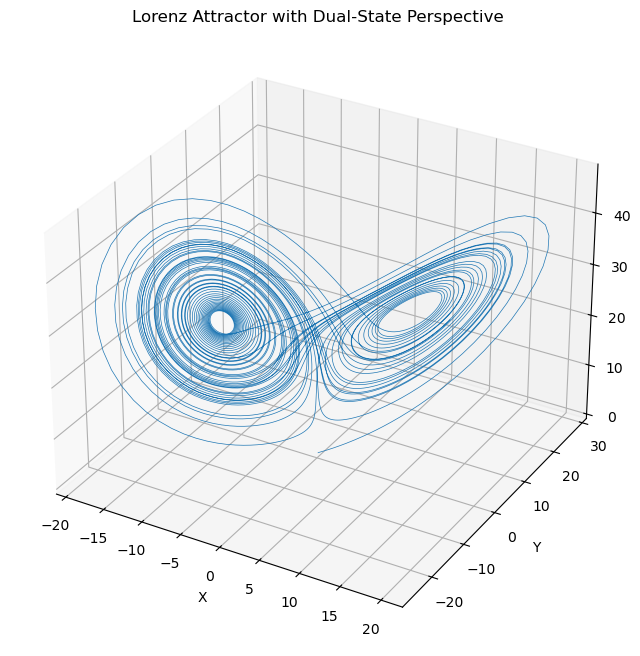

In [13]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define Lorenz attractor equations
def lorenz(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Initial state and time range
initial_state = [0.1, 0.1, 0.1]
time = np.linspace(0, 50, 5000)

# Simulate
states = odeint(lorenz, initial_state, time)

# Plot results
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(states[:, 0], states[:, 1], states[:, 2], lw=0.5)
ax.set_title("Lorenz Attractor with Dual-State Perspective")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


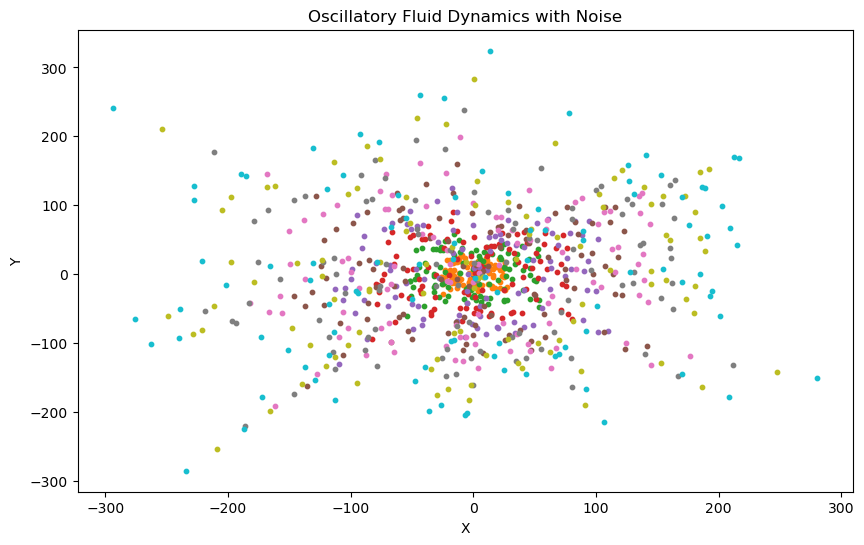

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize fluid particles
num_particles = 100
positions = np.random.rand(num_particles, 2)  # X, Y positions
velocities = np.random.rand(num_particles, 2) - 0.5  # Random velocity

# Simulation parameters
num_steps = 500
positions_history = []

# Simulate particle motion
for step in range(num_steps):
    # Apply random noise to velocities (turbulence)
    turbulence = np.random.normal(scale=0.01, size=velocities.shape)
    velocities += turbulence

    # Update positions
    positions += velocities
    positions_history.append(positions.copy())

# Visualize fluid motion
plt.figure(figsize=(10, 6))
for snapshot in positions_history[::50]:  # Plot every 50 steps
    plt.scatter(snapshot[:, 0], snapshot[:, 1], s=10)
plt.title("Oscillatory Fluid Dynamics with Noise")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


# FOR BYTE 1

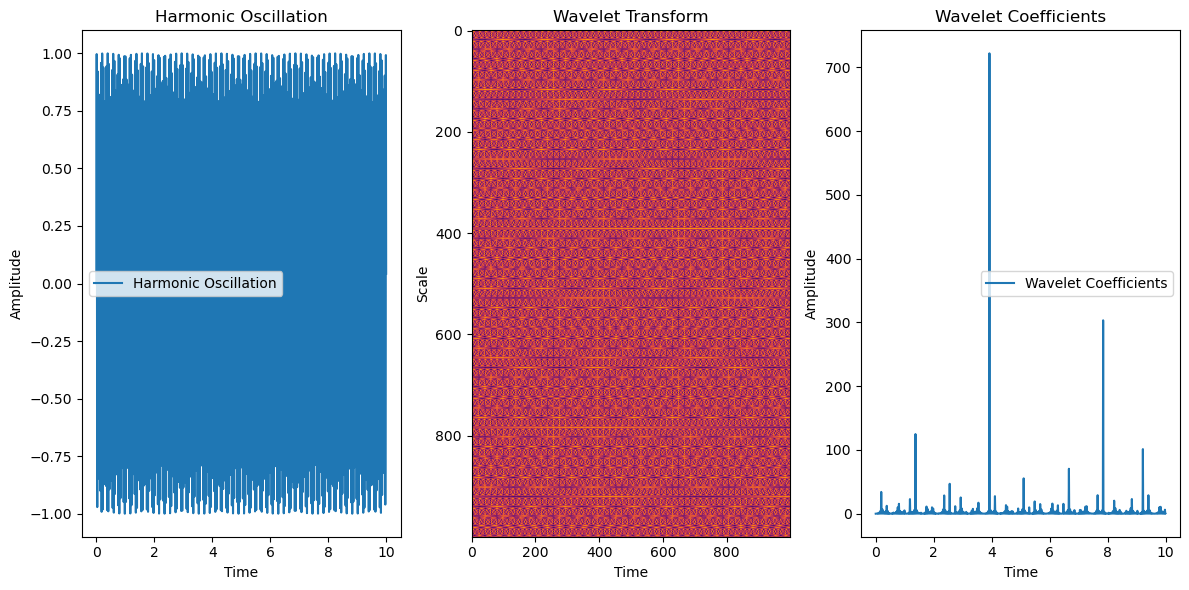

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
N = 1000  # Number of self-similar patterns
S = 2     # Scaling factor
omega = 2048 # Frequency
t = np.linspace(0, 10, 1000)  # Time array

# Calculate fractal dimension
D = np.log(N) / np.log(S)

# Generate harmonic oscillation
x = np.sin(omega * t)

# Generate wavelet transform
wavelet_coeffs = np.zeros((N, len(t)))
for i in range(N):
    wavelet_coeffs[i] = np.sin((i+1) * omega * t)

# Plot results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.plot(t, x, label='Harmonic Oscillation')
plt.title('Harmonic Oscillation')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(1, 3, 2)
plt.imshow(wavelet_coeffs, cmap='inferno', aspect='auto')
plt.title('Wavelet Transform')
plt.xlabel('Time')
plt.ylabel('Scale')

plt.subplot(1, 3, 3)
plt.plot(t, np.abs(np.sum(wavelet_coeffs, axis=0)), label='Wavelet Coefficients')
plt.title('Wavelet Coefficients')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

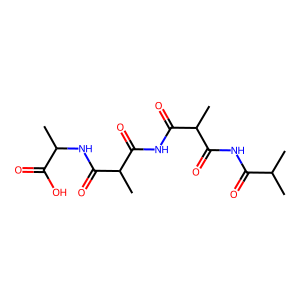

In [19]:
from rdkit import Chem
from rdkit.Chem import Draw

# Load the structure from the given molecular image
# Using the visual representation, manually encode the SMILES as accurately as possible for the peptide shown.
# Based on the image analysis, let's generate its SMILES
image_smiles = "CC(C(=O)O)NC(=O)C(C(=O)NC(=O)C(C(=O)NC(=O)C(C)C)C)C"

# Create a molecule object
molecule = Chem.MolFromSmiles(image_smiles)

# Draw the molecule to confirm accuracy
Draw.MolToImage(molecule)
